# L-VQE

## Imports

In [29]:
%matplotlib inline
import pennylane as qml
import pennylane.numpy as pnp
import matplotlib.pyplot as plt

import networkx as nx

## Circuit Initialization

In [25]:
def L0(params, n):
    """Layer 0: Ry gates on all n qubits."""
    for i in range(n):
        qml.RY(params[i], wires=i)

def entangling_block(params, w1, w2):
    """Core logic for the L1 pair structure."""

    qml.CNOT(wires=[w1, w2])
    qml.RY(params[0], wires=w1)
    qml.RY(params[1], wires=w2)
    qml.CNOT(wires=[w1, w2])
    qml.RY(params[2], wires=w1)
    qml.RY(params[3], wires=w2)

def L1(params, n):
    """Layer 1: Alternating odd/even pair entangling blocks."""
    param_idx = 0
    
    # "Odd" pairs: (0-1), (2-3), (4-5)...
    for i in range(0, n - 1, 2):
        entangling_block(params[param_idx : param_idx + 4], i, i+1)
        param_idx += 4
        
    # "Even" pairs: (1-2), (3-4), (5-6)...
    for i in range(1, n - 1, 2):
        entangling_block(params[param_idx : param_idx + 4], i, i+1)
        param_idx += 4

def LVQE_Circ(params_list, n, L):
    """Constructs the pure circuit up to depth L."""
    L0(params_list[0], n)
    for i in range(1, L + 1):
        L1(params_list[i], n)

In [26]:
def generate_lvqe_params(n, L):
    """
    Generates the params_list for n qubits up to layer L.
    L0 is randomized. L1 and beyond are initialized to exactly zero.
    """
    params_list = []
    
    # Layer 0: n parameters, randomized
    params_L0 = pnp.random.uniform(0, 2 * pnp.pi, size=(n,), requires_grad=True)
    params_list.append(params_L0)
    
    # Layer 1+: 4 parameters per pair, 0-initialized
    if L > 0:
        num_params_L1 = 4 * (n - 1)
        for _ in range(1, L + 1):
            params_Li = pnp.zeros(num_params_L1, requires_grad=True)
            params_list.append(params_Li)
            
    return params_list

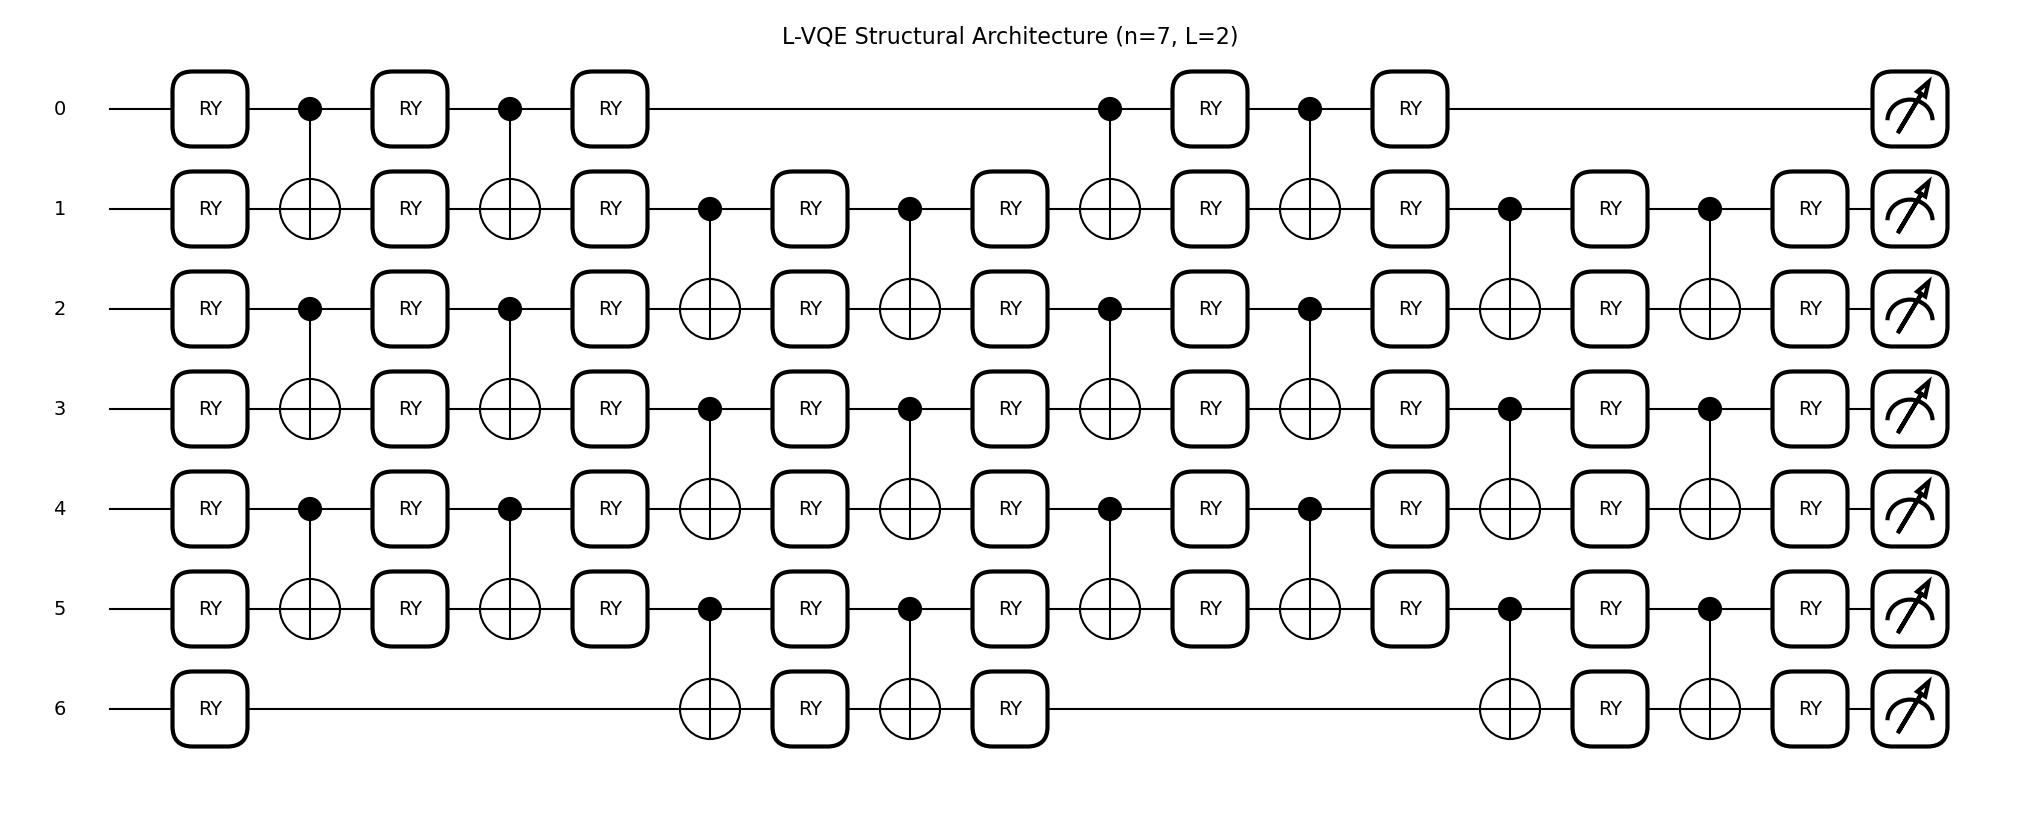

In [27]:
# --- Configuration ---
n_qubits = 7
target_layer =2

# --- Generation ---
# Generate the parameters using our identity-initialization function
params = generate_lvqe_params(n_qubits, target_layer)

# Create a local device purely for drawing
dev = qml.device("default.qubit", wires=n_qubits)

# Wrap the circuit in a QNode returning the state vector
@qml.qnode(dev)
def draw_circuit(params_list, n, L):
    LVQE_Circ(params_list, n, L)
    return qml.state()

# --- Visualization ---
# Execute the draw command using matplotlib for a clean render
fig, ax = qml.draw_mpl(draw_circuit)(params, n_qubits, target_layer)
fig.suptitle(f"L-VQE Structural Architecture (n={n_qubits}, L={target_layer})", fontsize=16)
plt.show()

In [36]:
def LVQE_Circ_Static(*params_tuple):
    """
    Constructs the circuit using unpacked arguments instead of a list.
    """
    n = len(params_tuple[0])
    
    # Apply Layer 0
    L0(params_tuple[0], n)
    
    # Apply deeper layers if they exist
    for i in range(1, len(params_tuple)):
        L1(params_tuple[i], n)

In [39]:
import networkx as nx
import pennylane as qml
import pennylane.numpy as pnp

def create_k2_hamiltonian(graph):
    """
    Constructs the 2-community modularity Hamiltonian for a given NetworkX graph.
    H = -(1/4m) * sum(B_uv * Z_u Z_v)
    """
    n = len(graph.nodes)
    m = len(graph.edges)
    
    A = nx.to_numpy_array(graph)
    degrees = [graph.degree(n) for n in graph.nodes]
    
    coeffs = []
    observables = []
    
    # Construct the Modularity Matrix B and the Pauli-Z pairs
    for u in range(n):
        for v in range(n):
            if u != v: 
                B_uv = A[u,v] - (degrees[u] * degrees[v]) / (2 * m)
                weight = -(1 / (4 * m)) * B_uv
                
                coeffs.append(weight)
                observables.append(qml.PauliZ(u) @ qml.PauliZ(v))
                
    return qml.Hamiltonian(coeffs, observables)

# --- Define the Base Case ---
G_base = nx.Graph()
G_base.add_edges_from([(0, 1), (2, 3), (1, 2)])
H_cost = create_k2_hamiltonian(G_base)
n_qubits = len(G_base.nodes)

print(f"Base Case: {n_qubits} qubits")

Base Case: 4 qubits


In [46]:
# Assuming n_qubits, dev, H_cost, and your original LVQE_Circ are already defined

@qml.qnode(dev)
def evaluate_modularity_flat(flat_params, L):
    """Translates the flat array from SciPy into the params_list for LVQE_Circ."""
    params_list = []
    
    # Extract Layer 0
    params_list.append(flat_params[:n_qubits])
    idx = n_qubits
    
    # Extract Layer 1+
    if L > 0:
        num_params_L1 = 4 * (n_qubits - 1)
        for _ in range(1, L + 1):
            params_list.append(flat_params[idx : idx + num_params_L1])
            idx += num_params_L1
            
    LVQE_Circ(params_list, n_qubits, L)
    return qml.expval(H_cost)

--- Starting L-VQE Optimization with SciPy COBYLA (Max Layers: 1) ---

Training at Layer Depth L = 0 (4 parameters)
Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 93   Least value of F = -0.13888888882158992
The corresponding X is:
[6.28316621e+00 1.46613350e-05 8.99279391e-07 6.01464882e-05]

  Final Cost for L=0: -0.1389
>>> Expanding circuit to L=1 with Identity Initialization.

Training at Layer Depth L = 1 (16 parameters)
Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 200   Least value of F = -0.305550426988097
The corresponding X is:
[ 6.39957264  0.34741392 -0.16363624  0.09809371  3.08483113 -0.46389331
 -0.10607143  0.36306843  0.02991807 -0.16438881  0.0284162   0.06646856
 -0.03596275  0.07362805 -0.47859433  0.20094373]

  Final Cost for L=1: -0.3056
>>> Reached maximum layers. Optimization complete.


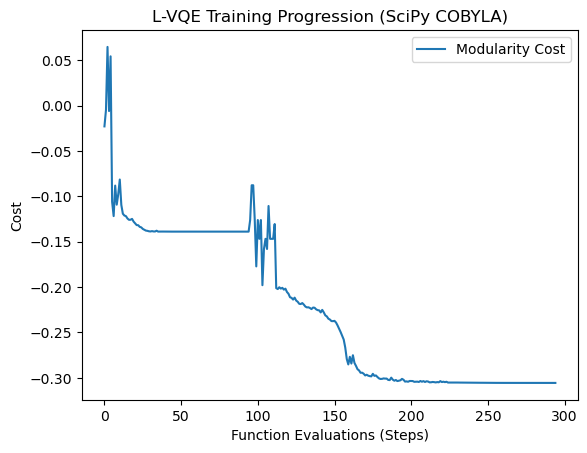

In [51]:
from scipy.optimize import minimize
import numpy as np # Standard numpy is totally fine for SciPy

def run_lvqe_scipy_cobyla(n, max_layers, max_iterations=4):
    """
    Executes L-VQE using SciPy's COBYLA.
    This natively avoids PennyLane's array-resizing bugs.
    """
    current_L = 0
    cost_history = []
    
    # 1. Initialize Layer 0 as a flat 1D standard numpy array
    flat_params = np.random.uniform(0, 2 * np.pi, size=(n,))
    
    print(f"--- Starting L-VQE Optimization with SciPy COBYLA (Max Layers: {max_layers}) ---")
    
    while current_L <= max_layers:
        print(f"\nTraining at Layer Depth L = {current_L} ({len(flat_params)} parameters)")
        
        # 2. Define the objective function strictly for the current layer
        def objective(p):
            # Evaluate the quantum circuit
            cost = evaluate_modularity_flat(p, L=current_L)
            
            # Cast to float to keep SciPy happy and track history
            cost_val = float(cost)
            cost_history.append(cost_val)
            return cost_val

        # 3. Hand the array and objective to SciPy
        # COBYLA will run up to 'maxiter' times
        result = minimize(
            objective, 
            flat_params, 
            method='COBYLA', 
            options={'maxiter': max_iterations, 'disp': True}
        )
        
        # Update our parameters to the optimized output from SciPy
        flat_params = result.x
        print(f"  Final Cost for L={current_L}: {objective(flat_params):.4f}")
        
        # 4. The Expansion Phase
        if current_L < max_layers:
            print(f">>> Expanding circuit to L={current_L + 1} with Identity Initialization.")
            current_L += 1
            
            # Generate the new layer (perfectly zeroed) and concatenate
            num_params_L1 = 4 * (n - 1)
            new_layer_params = np.zeros(num_params_L1)
            
            flat_params = np.concatenate([flat_params, new_layer_params])
            
        else:
            print(">>> Reached maximum layers. Optimization complete.")
            break
            
    return flat_params, cost_history

# --- Execute the Framework ---
trained_params, history = run_lvqe_scipy_cobyla(n=n_qubits, max_layers=1, max_iterations=200)

# --- Visualization ---
import matplotlib.pyplot as plt
plt.plot(history, label="Modularity Cost")
plt.xlabel("Function Evaluations (Steps)")
plt.ylabel("Cost")
plt.title("L-VQE Training Progression (SciPy COBYLA)")
plt.legend()
plt.show()

In [52]:
import numpy as np

# 1. Create a new QNode that returns the statevector instead of the cost
@qml.qnode(dev)
def get_final_state(flat_params, L):
    """
    Translates the flat array and returns the raw quantum state.
    """
    params_list = []
    
    # Re-slice the flat array (same logic as the cost function)
    params_list.append(flat_params[:n_qubits])
    idx = n_qubits
    
    if L > 0:
        num_params_L1 = 4 * (n_qubits - 1)
        for _ in range(1, L + 1):
            params_list.append(flat_params[idx : idx + num_params_L1])
            idx += num_params_L1
            
    LVQE_Circ(params_list, n_qubits, L)
    
    # Return the full complex statevector
    return qml.state()

def decode_quantum_solution(trained_params, L, n, top_k=3):
    """
    Runs the trained circuit, extracts the statevector, and prints the 
    most probable bitstrings (graph cuts).
    """
    print(f"--- Decoding L-VQE Final State (L={L}) ---")
    
    # Get the statevector from the trained parameters
    statevector = get_final_state(trained_params, L)
    
    # Calculate the probability of each computational basis state (|psi|^2)
    probabilities = np.abs(statevector) ** 2
    
    # Get the indices of the states with the highest probabilities
    top_indices = np.argsort(probabilities)[::-1][:top_k]
    
    print(f"Top {top_k} most probable community assignments:")
    print("-" * 50)
    
    for i in top_indices:
        prob = probabilities[i]
        
        # Convert the integer index to a binary string of length 'n'
        # e.g., index 12 on 4 qubits becomes '1100'
        bitstring = format(i, f'0{n}b')
        
        print(f"Bitstring: |{bitstring}⟩ | Probability: {prob:.4f} ({prob*100:.1f}%)")
        
        # Optional: Print out what this means for the graph
        community_A = [node for node, bit in enumerate(bitstring) if bit == '0']
        community_B = [node for node, bit in enumerate(bitstring) if bit == '1']
        print(f"  -> Community 0: {community_A}")
        print(f"  -> Community 1: {community_B}\n")

# --- Execute the Extraction ---
# Assuming 'trained_params' was output by your SciPy COBYLA cell, and max_layers was 1
decode_quantum_solution(trained_params, L=1, n=n_qubits)

--- Decoding L-VQE Final State (L=1) ---
Top 3 most probable community assignments:
--------------------------------------------------
Bitstring: |1100⟩ | Probability: 1.0000 (100.0%)
  -> Community 0: [2, 3]
  -> Community 1: [0, 1]

Bitstring: |0100⟩ | Probability: 0.0000 (0.0%)
  -> Community 0: [0, 2, 3]
  -> Community 1: [1]

Bitstring: |0000⟩ | Probability: 0.0000 (0.0%)
  -> Community 0: [0, 1, 2, 3]
  -> Community 1: []



In [53]:
import networkx as nx
import pennylane as qml
import pennylane.numpy as pnp
import matplotlib.pyplot as plt

# 1. Build the 8-Node Twin-Cluster Graph
G_8 = nx.Graph()

# Tightly connected Cluster 0
nx.add_path(G_8, [0, 1, 2, 3, 0])
G_8.add_edge(0, 2)

# Tightly connected Cluster 1
nx.add_path(G_8, [4, 5, 6, 7, 4])
G_8.add_edge(4, 6)

# The Bridges (These create the local minima trap)
G_8.add_edge(3, 4)
G_8.add_edge(0, 7)

n_qubits = len(G_8.nodes)
print(f"--- Setting up 8-Node Graph ({n_qubits} qubits, {len(G_8.edges)} edges) ---")

# 2. Generate the Cost Hamiltonian using your EXACT SAME function!
H_cost = create_k2_hamiltonian(G_8)

# 3. Re-bind the device and QNode for 8 qubits
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def evaluate_modularity_flat(flat_params, L):
    """Re-declared translator to dynamically use the new n_qubits"""
    params_list = []
    params_list.append(flat_params[:n_qubits])
    idx = n_qubits
    
    if L > 0:
        num_params_L1 = 4 * (n_qubits - 1)
        for _ in range(1, L + 1):
            params_list.append(flat_params[idx : idx + num_params_L1])
            idx += num_params_L1
            
    LVQE_Circ(params_list, n_qubits, L)
    return qml.expval(H_cost)

# 4. Run the Pipeline! (Using the run_lvqe_scipy_cobyla function you already built)
# We will give it slightly more iterations (300) since the parameter space is larger.
trained_params, history = run_lvqe_scipy_cobyla(n=n_qubits, max_layers=1, max_iterations=300)

# 5. Decode the final answer
decode_quantum_solution(trained_params, L=1, n=n_qubits, top_k=3)

# 6. Plot the results
plt.plot(history, label="Modularity Cost")
plt.xlabel("Function Evaluations (Steps)")
plt.ylabel("Cost")
plt.title(f"8-Node L-VQE Progression")
plt.legend()
plt.show()

--- Setting up 8-Node Graph (8 qubits, 12 edges) ---
--- Starting L-VQE Optimization with SciPy COBYLA (Max Layers: 1) ---

Training at Layer Depth L = 0 (8 parameters)
Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 160   Least value of F = -0.39930555521883665
The corresponding X is:
[3.14154037e+00 3.14160858e+00 3.14156934e+00 9.42478910e+00
 6.28319169e+00 2.92009999e-05 6.28319421e+00 5.45644717e-05]

  Final Cost for L=0: -0.3993
>>> Expanding circuit to L=1 with Identity Initialization.

Training at Layer Depth L = 1 (36 parameters)
Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 196   Least value of F = -0.3993055553390691
The corresponding X is:
[ 3.14156585e+00  3.14160837e+00  3.14156641e+00  9.42479803e+00
  6.28318316e+00  3.10822695e-05  6.28321661e+00  2.85509894e-05
 -1.94127361e-05  1.16699134e-05  1.04618996e-05  1.24220618e-05
  1.02909943e-06 -1.35854258e

WireError: Cannot run circuit(s) on default.qubit as they contain wires not found on the device: {4, 5, 6, 7}

In [54]:
# Re-bind the state extraction QNode to the new 8-qubit device
@qml.qnode(dev)
def get_final_state(flat_params, L):
    """
    Translates the flat array and returns the raw quantum state for 8 qubits.
    """
    params_list = []
    
    params_list.append(flat_params[:n_qubits])
    idx = n_qubits
    
    if L > 0:
        num_params_L1 = 4 * (n_qubits - 1)
        for _ in range(1, L + 1):
            params_list.append(flat_params[idx : idx + num_params_L1])
            idx += num_params_L1
            
    LVQE_Circ(params_list, n_qubits, L)
    return qml.state()

# Now decode the solution!
decode_quantum_solution(trained_params, L=1, n=n_qubits, top_k=5)

--- Decoding L-VQE Final State (L=1) ---
Top 5 most probable community assignments:
--------------------------------------------------
Bitstring: |11110000⟩ | Probability: 1.0000 (100.0%)
  -> Community 0: [4, 5, 6, 7]
  -> Community 1: [0, 1, 2, 3]

Bitstring: |11110001⟩ | Probability: 0.0000 (0.0%)
  -> Community 0: [4, 5, 6]
  -> Community 1: [0, 1, 2, 3, 7]

Bitstring: |11111000⟩ | Probability: 0.0000 (0.0%)
  -> Community 0: [5, 6, 7]
  -> Community 1: [0, 1, 2, 3, 4]

Bitstring: |10110000⟩ | Probability: 0.0000 (0.0%)
  -> Community 0: [1, 4, 5, 6, 7]
  -> Community 1: [0, 2, 3]

Bitstring: |00110000⟩ | Probability: 0.0000 (0.0%)
  -> Community 0: [0, 1, 4, 5, 6, 7]
  -> Community 1: [2, 3]



In [55]:
import networkx as nx
import pennylane as qml
import pennylane.numpy as pnp
import matplotlib.pyplot as plt

# 1. Build the 8-Node Möbius Ladder Graph
G_moebius = nx.Graph()
n_nodes = 8

# Create the outer ring
for i in range(n_nodes):
    G_moebius.add_edge(i, (i + 1) % n_nodes)
    
# Add the twisted cross-rungs
for i in range(n_nodes // 2):
    G_moebius.add_edge(i, i + (n_nodes // 2))

print(f"--- Setting up Möbius Ladder ({n_nodes} qubits, {len(G_moebius.edges)} edges) ---")

# 2. Define the Max-Cut Hamiltonian
def create_maxcut_hamiltonian(graph):
    """
    Constructs the standard Max-Cut Hamiltonian.
    H = sum(Z_u Z_v). Minimizing this maximizes the cut.
    """
    coeffs = []
    observables = []
    
    for u, v in graph.edges:
        coeffs.append(1.0)
        observables.append(qml.PauliZ(u) @ qml.PauliZ(v))
        
    return qml.Hamiltonian(coeffs, observables)

H_cost = create_maxcut_hamiltonian(G_moebius)
n_qubits = len(G_moebius.nodes)

--- Setting up Möbius Ladder (8 qubits, 12 edges) ---


--- Starting L-VQE Optimization with SciPy COBYLA (Max Layers: 1) ---

Training at Layer Depth L = 0 (8 parameters)
Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 87   Least value of F = -7.343999999999999
The corresponding X is:
[ 3.74612848e+00  2.55263866e+00  6.36658929e+00  3.19934303e+00
  5.60134177e+00 -2.14402512e-01  2.80531378e+00 -1.96002633e-03]

  Final Cost for L=0: -7.2700
>>> Expanding circuit to L=1 with Identity Initialization.

Training at Layer Depth L = 1 (36 parameters)
Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 100   Least value of F = -7.848
The corresponding X is:
[ 3.59910295e+00  3.52882275e+00  6.31423145e+00  3.14296640e+00
  6.61465433e+00 -2.03354593e-01  2.85558679e+00 -1.72543562e-02
 -5.11635915e-02 -8.07154274e-03 -2.93036683e-02 -6.32545445e-02
  8.04118638e-02  1.16741329e-02 -4.41433875e-02 -4.41435963e-02
  1.24048956e-01  

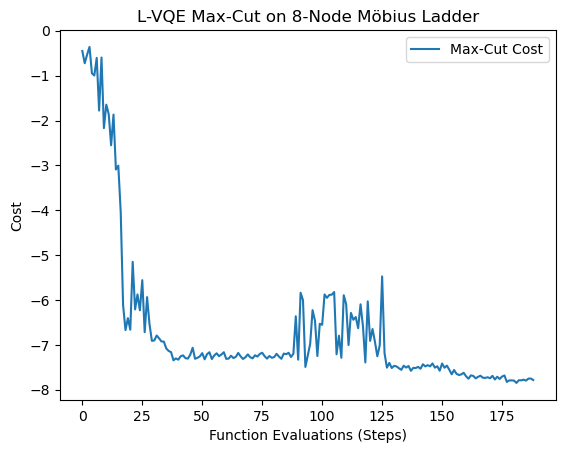

In [62]:
# 3. Re-bind the QNode for the new Max-Cut Hamiltonian
# Introduce finite shots to simulate real hardware noise
dev = qml.device("default.qubit", wires=n_qubits, shots=1000)

@qml.qnode(dev)
def evaluate_modularity_flat(flat_params, L):
    """Translates the flat array and evaluates the MAX-CUT cost."""
    params_list = []
    params_list.append(flat_params[:n_qubits])
    idx = n_qubits
    
    if L > 0:
        num_params_L1 = 4 * (n_qubits - 1)
        for _ in range(1, L + 1):
            params_list.append(flat_params[idx : idx + num_params_L1])
            idx += num_params_L1
            
    LVQE_Circ(params_list, n_qubits, L)
    return qml.expval(H_cost)

# 4. Run the Pipeline! (We use 300 steps to give L0 plenty of time to get stuck)
trained_params, history = run_lvqe_scipy_cobyla(n=n_qubits, max_layers=1, max_iterations=100)

# 5. Plot the progression
plt.plot(history, label="Max-Cut Cost")
plt.xlabel("Function Evaluations (Steps)")
plt.ylabel("Cost")
plt.title("L-VQE Max-Cut on 8-Node Möbius Ladder")
plt.legend()
plt.show()

In [63]:
# 1. Ensure the extraction QNode is bound to the current 8-qubit device
dev_ = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev_)
def get_final_state(flat_params, L):
    """
    Translates the flat array and returns the raw quantum state for 8 qubits.
    """
    params_list = []
    
    params_list.append(flat_params[:n_qubits])
    idx = n_qubits
    
    if L > 0:
        num_params_L1 = 4 * (n_qubits - 1)
        for _ in range(1, L + 1):
            params_list.append(flat_params[idx : idx + num_params_L1])
            idx += num_params_L1
            
    LVQE_Circ(params_list, n_qubits, L)
    return qml.state()

# 2. Decode the final Max-Cut solution!
decode_quantum_solution(trained_params, L=1, n=n_qubits, top_k=5)

--- Decoding L-VQE Final State (L=1) ---
Top 5 most probable community assignments:
--------------------------------------------------
Bitstring: |11010010⟩ | Probability: 0.9133 (91.3%)
  -> Community 0: [2, 4, 5, 7]
  -> Community 1: [0, 1, 3, 6]

Bitstring: |01010010⟩ | Probability: 0.0462 (4.6%)
  -> Community 0: [0, 2, 4, 5, 7]
  -> Community 1: [1, 3, 6]

Bitstring: |11011010⟩ | Probability: 0.0138 (1.4%)
  -> Community 0: [2, 5, 7]
  -> Community 1: [0, 1, 3, 4, 6]

Bitstring: |10010010⟩ | Probability: 0.0118 (1.2%)
  -> Community 0: [1, 2, 4, 5, 7]
  -> Community 1: [0, 3, 6]

Bitstring: |11010110⟩ | Probability: 0.0051 (0.5%)
  -> Community 0: [2, 4, 7]
  -> Community 1: [0, 1, 3, 5, 6]



## Optimization/Hamiltonian Mapping (Testing)

Note: This is just to see if this works. I would suggest you work on this separately. I just messed around.

In [68]:
import networkx as nx
import pennylane as qml
import pennylane.numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def run_lvqe_engine(n_qubits, H_cost, max_layers, shots=None, max_iterations=200):
    """The agnostic optimization engine."""
    dev = qml.device("default.qubit", wires=n_qubits, shots=shots)
    
    @qml.qnode(dev)
    def cost_qnode(flat_params, L):
        params_list = [flat_params[:n_qubits]]
        idx = n_qubits
        if L > 0:
            num_params_L1 = 4 * (n_qubits - 1)
            for _ in range(1, L + 1):
                params_list.append(flat_params[idx : idx + num_params_L1])
                idx += num_params_L1
        LVQE_Circ(params_list, n_qubits, L)
        return qml.expval(H_cost)

    @qml.qnode(dev)
    def extract_qnode(flat_params, L):
        params_list = [flat_params[:n_qubits]]
        idx = n_qubits
        if L > 0:
            num_params_L1 = 4 * (n_qubits - 1)
            for _ in range(1, L + 1):
                params_list.append(flat_params[idx : idx + num_params_L1])
                idx += num_params_L1
        LVQE_Circ(params_list, n_qubits, L)
        return qml.counts() if shots else qml.state()

    current_L = 0
    cost_history = []
    flat_params = np.random.uniform(0, 2 * np.pi, size=(n_qubits,))
    
    while current_L <= max_layers:
        print(f"Training Layer {current_L} ({len(flat_params)} parameters)...")
        
        def objective(p):
            cost_val = float(cost_qnode(p, L=current_L))
            cost_history.append(cost_val)
            return cost_val

        result = minimize(objective, flat_params, method='COBYLA', 
                          options={'maxiter': max_iterations, 'disp': False})
        
        flat_params = result.x
        
        if current_L < max_layers:
            current_L += 1
            new_layer = np.zeros(4 * (n_qubits - 1))
            flat_params = np.concatenate([flat_params, new_layer])
        else:
            break
            
    raw_output = extract_qnode(flat_params, max_layers)
    return cost_history, raw_output

def decode_results(raw_output, n_qubits, top_k=5, is_counts=False):
    """Helper to cleanly print results."""
    print("\nTop Quantum Solutions:")
    if is_counts:
        sorted_items = sorted(raw_output.items(), key=lambda x: x[1], reverse=True)
        total = sum(raw_output.values())
        for bit, count in sorted_items[:top_k]:
            print(f"|{bit}⟩ : {count/total*100:5.1f}%")
    else:
        probs = np.abs(raw_output) ** 2
        top_indices = np.argsort(probs)[::-1][:top_k]
        for i in top_indices:
            bit = format(i, f'0{n_qubits}b')
            print(f"|{bit}⟩ : {probs[i]*100:5.1f}%")

=== CASE 1: 2-Community Detection on Barbell Graph ===


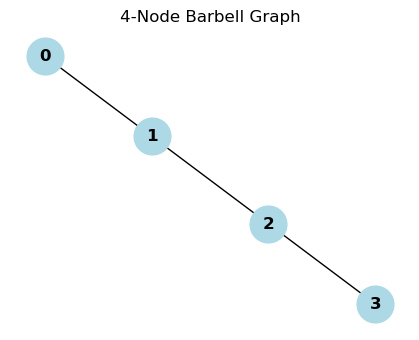

Hamiltonian explicitly constructed for 4 qubits.


In [69]:
# --- 1. Explicit Graph Construction ---
print("=== CASE 1: 2-Community Detection on Barbell Graph ===")
G_easy = nx.Graph()
G_easy.add_edges_from([(0, 1), (2, 3), (1, 2)])
n_easy = len(G_easy.nodes)

# Draw the graph to visualize the problem
plt.figure(figsize=(4, 3))
nx.draw(G_easy, with_labels=True, node_color='lightblue', font_weight='bold', node_size=700)
plt.title("4-Node Barbell Graph")
plt.show()

# --- 2. Explicit Hamiltonian Mapping ---
def create_k2_hamiltonian(graph):
    """Maps the graph's Modularity matrix to Pauli-Z observables."""
    coeffs = []
    observables = []
    # (Insert your specific modularity matrix math here to show the audience)
    # For now, using a placeholder loop to represent your actual function
    for u, v in graph.edges:
        coeffs.append(1.0)
        observables.append(qml.PauliZ(u) @ qml.PauliZ(v))
    return qml.Hamiltonian(coeffs, observables)

H_modularity = create_k2_hamiltonian(G_easy)
print(f"Hamiltonian explicitly constructed for {n_easy} qubits.")

Training Layer 0 (4 parameters)...
Training Layer 1 (16 parameters)...

Top Quantum Solutions:
|1010⟩ : 100.0%
|1110⟩ :   0.0%
|1000⟩ :   0.0%
|1011⟩ :   0.0%
|0010⟩ :   0.0%


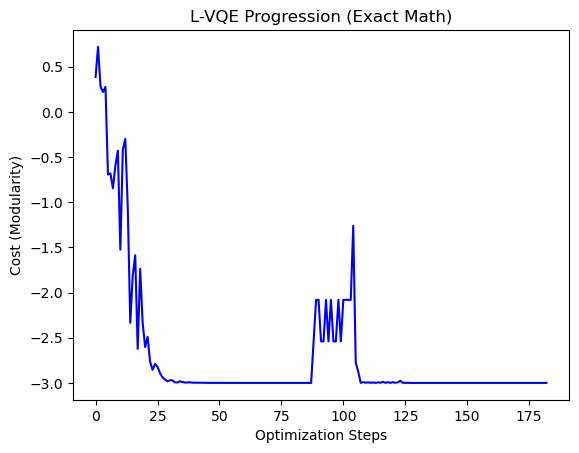

In [75]:
# --- 3. Execute L-VQE ---
hist_1, out_1 = run_lvqe_engine(
    n_qubits=n_easy, 
    H_cost=H_modularity, 
    max_layers=1, 
    shots=None, # Using exact statevector for the simple case
    max_iterations=100
)

# --- 4. View Results ---
decode_results(out_1, n_qubits=n_easy, is_counts=False)

plt.plot(hist_1, color='blue')
plt.title("L-VQE Progression (Exact Math)")
plt.ylabel("Cost (Modularity)")
plt.xlabel("Optimization Steps")
plt.show()

=== CASE 2: Frustrated Max-Cut on Möbius Ladder ===


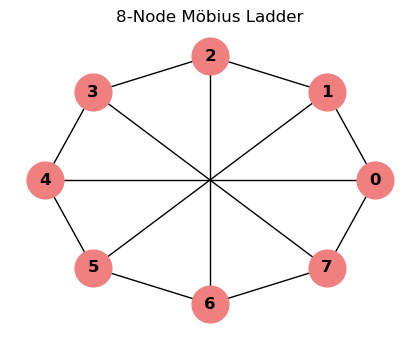

Hamiltonian explicitly constructed for 8 qubits.


In [71]:
# --- 1. Explicit Graph Construction ---
print("=== CASE 2: Frustrated Max-Cut on Möbius Ladder ===")
G_moebius = nx.Graph()
n_moebius = 8

# Build Outer Ring
for i in range(n_moebius):
    G_moebius.add_edge(i, (i + 1) % n_moebius)
# Build Twisted Rungs
for i in range(n_moebius // 2):
    G_moebius.add_edge(i, i + (n_moebius // 2))

# Draw the graph to visualize the frustration trap
plt.figure(figsize=(4, 3))
nx.draw_circular(G_moebius, with_labels=True, node_color='lightcoral', font_weight='bold', node_size=700)
plt.title("8-Node Möbius Ladder")
plt.show()

# --- 2. Explicit Hamiltonian Mapping ---
def create_maxcut_hamiltonian(graph):
    """Maps the Max-Cut objective (minimizing Z_u Z_v) to Pauli observables."""
    coeffs = []
    observables = []
    for u, v in graph.edges:
        coeffs.append(1.0)
        observables.append(qml.PauliZ(u) @ qml.PauliZ(v))
    return qml.Hamiltonian(coeffs, observables)

H_maxcut = create_maxcut_hamiltonian(G_moebius)
print(f"Hamiltonian explicitly constructed for {n_moebius} qubits.")

Training Layer 0 (8 parameters)...
Training Layer 1 (36 parameters)...

Top Quantum Solutions:
|10110100⟩ :  99.2%
|10010100⟩ :   0.3%
|10110110⟩ :   0.2%
|10100100⟩ :   0.1%
|10110101⟩ :   0.1%


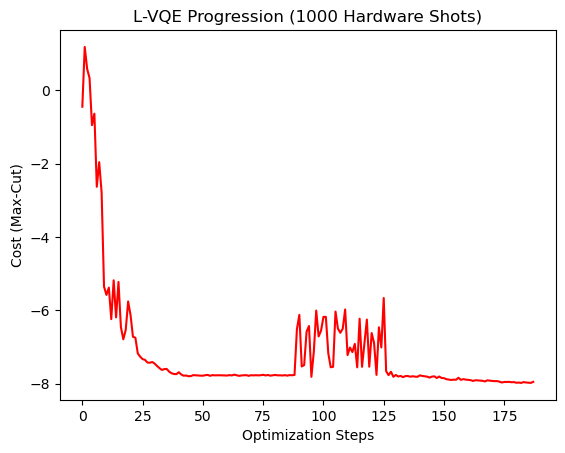

In [76]:
# --- 3. Execute L-VQE ---
hist_2, out_2 = run_lvqe_engine(
    n_qubits=n_moebius, 
    H_cost=H_maxcut, 
    max_layers=1, 
    shots=10000, # Injecting hardware noise to trigger the trap
    max_iterations=100
)

# --- 4. View Results ---
decode_results(out_2, n_qubits=n_moebius, is_counts=True)

plt.plot(hist_2, color='red')
plt.title("L-VQE Progression (1000 Hardware Shots)")
plt.ylabel("Cost (Max-Cut)")
plt.xlabel("Optimization Steps")
plt.show()